In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

%cd /home/smalani/PartialObservations

cwd = os.getcwd()
print(cwd)

/home/smalani/PartialObservations
/home/smalani/PartialObservations


In [2]:
from config import config
from main.utils import Network, MLP
import torch

f = np.load("minmax/minmax.npz")

xmax = f['arr_0']
xmin = f['arr_1']
print(xmax)
print(xmin)

norm_func = lambda input, device: (input - torch.tensor(xmin).float().to(device)) / \
                        ((torch.tensor((xmax - xmin)).float().to(device)) + 1e-10)
inv_norm_func = lambda input, device: input * ((torch.tensor((xmax - xmin)).float().to(device)) + 1e-10) \
                                + torch.tensor(xmin).float().to(device)

# Create the network architecture

if config["MODEL"]["BOX"] == 'Black':
    # Create the network architecture
    mlp = MLP(6, config["MODEL"]["NUM_HIDDEN"], 6)
    
    class my_Network(Network):
        def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                        inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                        tf_prop=1., integrator='RK4', add_par_num=0):
            super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                        inv_norm_func, init_available, device, 
                        tf_prop, integrator, add_par_num)

            self.additional_pars = torch.nn.Parameter((torch.zeros(6)-1).to(self.device), requires_grad = True) 

        def output(self, x, par):

            # ANN_input = torch.cat((self.norm_func(x), par/20), dim=-1)
            ANN_input_out = self.norm_func(x)
            ANN_input = torch.clip(ANN_input_out, min=-1., max=2.)
            out = self.net(ANN_input)
            out = self.inv_norm_func(out) * (100 ** (self.additional_pars))

            return out

elif config["MODEL"]["BOX"] == 'Grey' or config["MODEL"]["BOX"] == 'Gray':
    
    # Create the network architecture
    mlp = MLP(6, config["MODEL"]["NUM_HIDDEN"], 3)
    
    if config["MODEL"]["Parameters"] == 'Trainable':
        class my_Network(Network):
            def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                            inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                            tf_prop=1., integrator='RK4', add_par_num=2):
                super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                            inv_norm_func, init_available, device, 
                            tf_prop, integrator, add_par_num)

                self.additional_pars = torch.nn.Parameter((torch.cat(((torch.tensor([0.4476, -0.4859, -0.6419])), 
                                                                        (torch.zeros(4) + 1)))).to(self.device), 
                                                            requires_grad = True)

            def output(self, x_input, par):
                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input)
                ANN_output = ANN_output * (100 ** (self.additional_pars[:3]))

                x, y, z, u, v, g = torch.unbind(x_input, dim=-1)

                u1_prime_x, u2_prime_y, u3_prime_z = torch.unbind(ANN_output, dim=-1)                

                omega = self.additional_pars[-4] * 10
                sigma = self.additional_pars[-3] * 10
                rho = self.additional_pars[-2] / 10
                eta = self.additional_pars[-1]

                alpha, uf, _, _, _, _, _, _, uc1_prime, uc2_prime, uc3_prime = datagen.par_fun()

                output = []

                output.append(-alpha * x + u1_prime_x - uc1_prime * x)
                output.append(-alpha * y + u2_prime_y - uc2_prime * y)
                output.append(-alpha * z + u3_prime_z - uc3_prime * z)
                output.append(alpha * (uf - u) - u1_prime_x)
                output.append(-alpha * v + omega * u1_prime_x - u2_prime_y - sigma * u3_prime_z)
                output.append(-alpha * g + rho * u2_prime_y + eta * u3_prime_z)

                out = torch.stack((output), dim=-1)
                return out
            def raw_output(self, x_input, par):

                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input) * (100 ** (self.additional_pars[:3]))

                return ANN_output
    elif config["MODEL"]["Parameters"] == 'Fixed':
        class my_Network(Network):
            def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                            inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                            tf_prop=1., integrator='RK4', add_par_num=2):
                super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                            inv_norm_func, init_available, device, 
                            tf_prop, integrator, add_par_num)

                # self.additional_pars = torch.nn.Parameter((torch.zeros(2)-0.5).to(self.device), 
                #                             requires_grad = True)
                self.additional_pars = torch.nn.Parameter((torch.tensor([0.4476, -0.4859, -0.6419])).to(self.device), 
                                                                requires_grad = True)

                

            def output(self, x_input, par):
                
                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input)
                ANN_output = ANN_output * (100 ** (self.additional_pars))

                x, y, z, u, v, g = torch.unbind(x_input, dim=-1)
                u1_prime_x, u2_prime_y, u3_prime_z = torch.unbind(ANN_output, dim=-1)

                alpha, uf, omega, sigma, rho, eta, phi1, phi2, uc1_prime, uc2_prime, uc3_prime = datagen.par_fun(D=1/7.3, sf=2.5)

                output = []

                # output.append(-alpha * x + u1_prime * x - uc1_prime * x)
                # output.append(torch.zeros(output[-1].shape).to(self.device))
                # output.append(-alpha * z + u3_prime * z - uc3_prime * z)
                # output.append(alpha * (uf - u) - u1_prime * x)
                # output.append(-alpha * v + omega * u1_prime * x - u2_prime * y - sigma * u3_prime * z)
                # output.append(-alpha * g + rho * u2_prime * y + eta * u3_prime * z)

                output.append(-alpha * x + u1_prime_x - uc1_prime * x)

                output.append(-alpha * y + u2_prime_y - uc2_prime * y)
                # output.append(torch.zeros(output[-1].shape).to(self.device))

                output.append(-alpha * z + u3_prime_z - uc3_prime * z)
                output.append(alpha * (uf - u) - u1_prime_x)
                output.append(-alpha * v + omega * u1_prime_x - u2_prime_y - sigma * u3_prime_z)
                output.append(-alpha * g + rho * u2_prime_y + eta * u3_prime_z)

                out = torch.stack((output), dim=-1)
                return out
            def raw_output(self, x_input, par):

                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input) * (100 ** (self.additional_pars))

                return ANN_output

    else:
        raise ValueError("Tell me whether to train the parameters!")
else:
    raise ValueError("Tell me what box to use!")


network = my_Network(mlp, config["DATA"]["N_TRAIN"], 6, norm_func=norm_func, inv_norm_func=inv_norm_func, 
                      init_available=config["DATA"]["INIT_AVAILABLE"], integrator='RK4')
device = 'cpu'

filename = 'data/' + 'model_' + '.net'

print(filename)


state_dict = torch.load(filename, map_location=torch.device(device))
network.load_state_dict(state_dict, strict=False)

print(network)
network.double()

[7.76480999e+01 6.13450077e-02 3.52889567e-01 2.08507400e+02
 2.11354658e+03 8.21362308e-01]
[1.45181035e+01 1.12344629e-04 2.81247634e-01 3.24970859e+01
 3.97881635e+02 6.58996734e-01]
data/model_.net
my_Network(
  (net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=32, bias=True)
      (1): Linear(in_features=32, out_features=32, bias=True)
    )
    (activation): SiLU()
    (output_layer): Linear(in_features=32, out_features=6, bias=True)
  )
)


my_Network(
  (net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=32, bias=True)
      (1): Linear(in_features=32, out_features=32, bias=True)
    )
    (activation): SiLU()
    (output_layer): Linear(in_features=32, out_features=6, bias=True)
  )
)

In [3]:
f = np.load('minmax/limitcycle.npz')
myvar0 = f['arr_0']


f = np.load('minmax/limitcycle_detail.npz')
myvar0_detail = f['arr_0']

print(myvar0.shape)

(6, 20)


In [4]:
from sympy.utilities.iterables import multiset_permutations
import numpy as np

import itertools
x = np.linspace(0.98, 1.02, 11)
# x = np.linspace(1., 1.02, 1)
print(x)

p_arr = np.ones((6, 6*x.size))
print(p_arr.shape)

for j in range(x.size):
    for i in range(6):
        p_arr[i,6*j+i] = x[j]

parr = np.tile(p_arr,(myvar0.shape[1]))
myvar0arr = np.repeat(myvar0,(p_arr.shape[1]), axis=1)
RHS_Eval_vals = (parr * myvar0arr).T

print(RHS_Eval_vals.shape)

[0.98  0.984 0.988 0.992 0.996 1.    1.004 1.008 1.012 1.016 1.02 ]
(6, 66)
(1320, 6)


In [5]:
# data_train = datagen.generate_data(n_train=config["DATA"]["N_TRAIN"],
#                                    tmax=config["DATA"]["TMAX"],
#                                    x_sample_num=(config["DATA"]["X_SAMPLE_NUM"]-1)*10+1,
#                                    detail=True,
#                                    theta_random=False)

# RHS_Eval_vals = data_train[3]

In [6]:
from sympy.utilities.iterables import multiset_permutations
import numpy as np

import itertools
x = np.linspace(0.99, 1.01, 5)
p = itertools.product(x, repeat=6)

p_arr = np.array(list(p)).T

parr = np.tile(p_arr,(myvar0.shape[1]))
myvar0arr = np.repeat(myvar0,(p_arr.shape[1]), axis=1)
print(parr.shape)
print(myvar0arr.shape)

RHS_Eval_vals = (parr * myvar0arr).T
print(RHS_Eval_vals.shape)
print(myvar0arr[:,:2])
print(parr[:,:10])
print(RHS_Eval_vals[:4,:].T)
# print(myvar0arr)

(6, 312500)
(6, 312500)
(312500, 6)
[[5.00000000e+01 5.00000000e+01]
 [9.47035345e-28 9.47035345e-28]
 [2.85187797e-01 2.85187797e-01]
 [1.20150526e+02 1.20150526e+02]
 [1.25440965e+03 1.25440965e+03]
 [6.62657291e-01 6.62657291e-01]]
[[0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99 ]
 [0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99 ]
 [0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99 ]
 [0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99  0.99 ]
 [0.99  0.99  0.99  0.99  0.99  0.995 0.995 0.995 0.995 0.995]
 [0.99  0.995 1.    1.005 1.01  0.99  0.995 1.    1.005 1.01 ]]
[[4.95000000e+01 4.95000000e+01 4.95000000e+01 4.95000000e+01]
 [9.37564991e-28 9.37564991e-28 9.37564991e-28 9.37564991e-28]
 [2.82335919e-01 2.82335919e-01 2.82335919e-01 2.82335919e-01]
 [1.18949021e+02 1.18949021e+02 1.18949021e+02 1.18949021e+02]
 [1.24186555e+03 1.24186555e+03 1.24186555e+03 1.24186555e+03]
 [6.56030719e-01 6.59344005e-01 6.62657291e-01 6.65970578e-01]]


In [7]:
from BandFModel import datagen

print(RHS_Eval_vals.shape)
RHS_Eval_vals = RHS_Eval_vals.reshape((-1,6))
print(RHS_Eval_vals.shape)

ANN_output = network.output(torch.tensor(RHS_Eval_vals).reshape((-1,6)).to(network.device),
                             torch.tensor([6]).reshape((-1,1)).to(network.device)).cpu().detach().numpy()

pars = datagen.par_fun()
output = datagen.ode_fun(0., RHS_Eval_vals.T, pars)
print(ANN_output.shape)
print(output.shape)

(312500, 6)
(312500, 6)
(312500, 6)
(312500, 6)


In [8]:
from sympy.utilities.iterables import multiset_permutations
import numpy as np

import itertools
x = np.linspace(1., 1.01, 1)
p = itertools.product(x, repeat=6)

p_arr = np.array(list(p)).T

parr = np.tile(p_arr,(myvar0_detail.shape[1]))
myvar0arr = np.repeat(myvar0_detail,(p_arr.shape[1]), axis=1)

RHS_Eval_vals_LC = (parr * myvar0arr).T

from BandFModel import datagen

print(RHS_Eval_vals_LC.shape)
RHS_Eval_vals_LC = RHS_Eval_vals_LC.reshape((-1,6))
print(RHS_Eval_vals_LC.shape)

ANN_output_LC = network.output(torch.tensor(RHS_Eval_vals_LC).reshape((-1,6)).to(network.device),
                             torch.tensor([6]).reshape((-1,1)).to(network.device)).cpu().detach().numpy()

pars = datagen.par_fun()
output_LC = datagen.ode_fun(0., RHS_Eval_vals_LC.T, pars)

(2000, 6)
(2000, 6)


In [9]:
print(RHS_Eval_vals_LC.shape)
print(RHS_Eval_vals.shape)

(2000, 6)
(312500, 6)


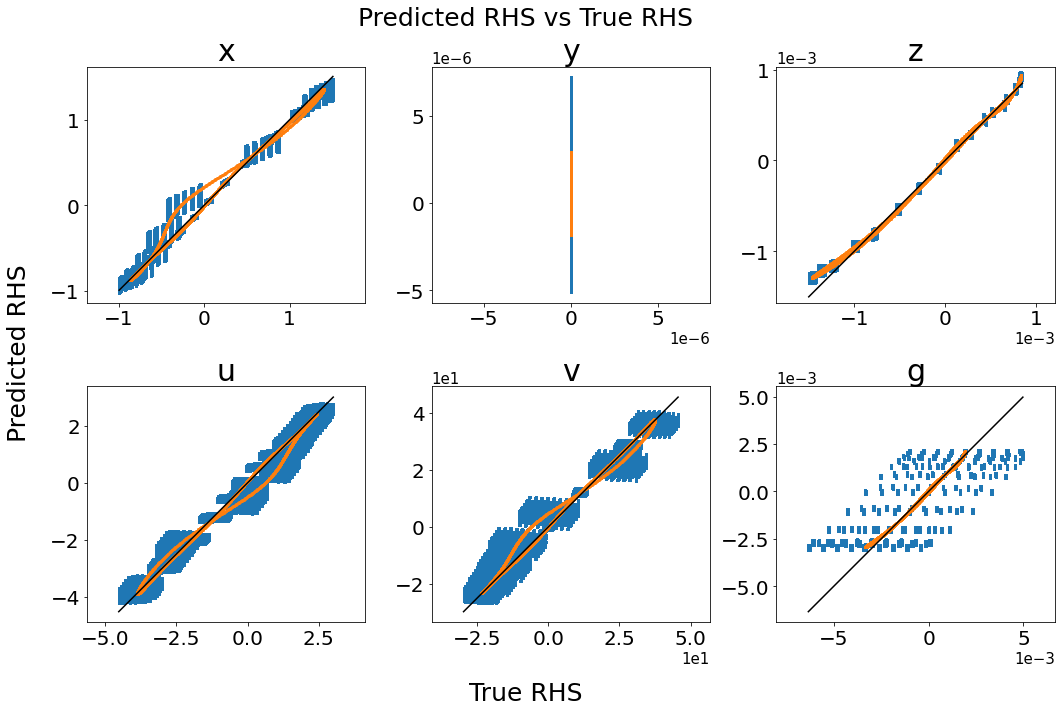

In [10]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15,10))

labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(23) + str(i+1)))
    axplot = ax.scatter(output[:,i], ANN_output[:,i], s=4) #c=time, cmap='jet', s=1)
    axplot = ax.scatter(output_LC[:,i], ANN_output_LC[:,i], s=4) #c=time, cmap='jet', s=1)
    ax.plot([np.min(output[:,i]), np.max(output[:,i])],[np.min(output[:,i]), np.max(output[:,i])], 'k-')
    # ax.set_ylabel('RHS of ' + labels[i] + ' (Pred)', fontsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
    ax.yaxis.offsetText.set_fontsize(15)
    # ax.set_xlabel('RHS of ' + labels[i] + ' (True)', fontsize=20)
    ax.tick_params(axis='x', labelsize=20) 
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    ax.xaxis.offsetText.set_fontsize(15)
    plt.title(labels[i], fontsize=30)

    # cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
    # cbar = fig.colorbar(axplot, ax=ax, cax=cax)
    # cbar.set_label('Time', rotation=270, fontsize=15, labelpad=15)
    ax.set_aspect("equal", adjustable="datalim")

plt.suptitle('Predicted RHS vs True RHS', fontsize=25)
# fig.text(0.5, 0.04, 'True RHS', ha='center', fontsize=25)
# fig.text(0.04, 0.5, 'Predicted RHS', va='center', rotation='vertical', fontsize=25)

fig.supylabel('Predicted RHS', fontsize=25)
fig.supxlabel('True RHS', fontsize=25)
plt.tight_layout()
# plt.savefig('Figures/Prediction_of_RHS.png')
plt.show()


In [11]:
print(RHS_Eval_vals.shape)

(312500, 6)


Text(0, 0.5, 'x')

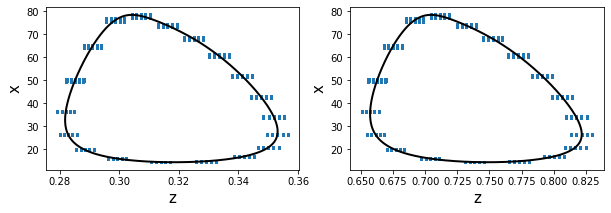

In [12]:
fig = plt.figure(figsize=(10,3))

ax = plt.subplot(int(str(12) + str(1)))
axplot = ax.scatter(RHS_Eval_vals[:,2], RHS_Eval_vals[:,0], s=4) #c=time, cmap='jet', s=1)
axplot = ax.plot(RHS_Eval_vals_LC[:,2], RHS_Eval_vals_LC[:,0], c='black', linewidth=2) #c=time, cmap='jet', s=1)
ax.set_xlabel('z', fontsize=15)
ax.set_ylabel('x', fontsize=15)

ax = plt.subplot(int(str(12) + str(2)))
axplot = ax.scatter(RHS_Eval_vals[:,5], RHS_Eval_vals[:,0], s=4) #c=time, cmap='jet', s=1)
axplot = ax.plot(RHS_Eval_vals_LC[:,5], RHS_Eval_vals_LC[:,0], c='black', linewidth=2) #c=time, cmap='jet', s=1)
ax.set_xlabel('z', fontsize=15)
ax.set_ylabel('x', fontsize=15)

In [13]:
print(output.shape)
print(ANN_output.shape)

RHSError_L1Norm = np.sum(np.sum(np.abs(output - ANN_output), axis=0) / (output.shape[0] * xmax))
RHSError_L2Norm = np.sum(np.sqrt(np.sum((output - ANN_output)**2, axis=0)) / (output.shape[0] * xmax))
RHSError_LinfNorm = np.sum(np.max(np.abs(output - ANN_output), axis=0) / (xmax))

print(RHSError_L1Norm)
print(RHSError_L2Norm)
print(RHSError_LinfNorm)

(312500, 6)
(312500, 6)
0.004954203170333214
1.1864750865447401e-05
0.026370501005995264


In [14]:
print(network.additional_pars)

Parameter containing:
tensor([-0.7970, -0.8598, -0.9007, -0.7112, -0.7447, -0.9035], device='cuda:0',
       dtype=torch.float64, requires_grad=True)
